In [1]:
# headlines.csv
# https://mitu.co.in/dataset

#### Import necessary libraries

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

#### Lead the dataset

In [8]:
df = pd.read_csv('datasets/headlines.csv', names = ['text'])

In [9]:
df.shape

(2225, 1)

In [10]:
df

,text
0,Budget to set scene for election\n \n Gordon B...
1,Army chiefs in regiments decision\n \n Militar...
2,Howard denies split over ID cards\n \n Michael...
3,Observers to monitor UK election\n \n Minister...
4,Kilroy names election seat target\n \n Ex-chat...
...,...
2220,India opens skies to competition\n \n India wi...
2221,Yukos bankruptcy 'not US matter'\n \n Russian ...
2222,Survey confirms property slowdown\n \n Governm...
2223,High fuel prices hit BA's profits\n \n British...


In [15]:
print(df['text'][0])

Budget to set scene for election
 
 Gordon Brown will seek to put the economy at the centre of Labour's bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The chancellor is expected to freeze petrol duty and raise the stamp duty threshold from Â£60,000. But the Conservatives and Lib Dems insist voters face higher taxes and more means-testing under Labour.
 
 Treasury officials have said there will not be a pre-election giveaway, but Mr Brown is thought to have about Â£2bn to spare.
 
 - Increase in the stamp duty threshold from Â£60,000 
  - A freeze on petrol duty 
  - An extension of tax credit scheme for poorer families 
  - Possible help for pensioners The stamp duty threshold rise is intended to help first time buyers - a likely theme of all three of the main parties' general election manifestos. Ten years ago, buyers had a much greater chanc

#### Data Preprocessing

In [17]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

In [18]:
swords = stopwords.words('english')

In [44]:
def clean_text(sent): 
    tokens1 = word_tokenize(sent)
    tokens2 = [token for token in tokens1 if token.isalpha()]
    tokens3 = [token.lower() for token in tokens2 
              if token.lower() not in swords]
    return tokens3

In [20]:
sent = 'The raining was expected today. But not completed.'

In [21]:
clean_text(sent)

['raining', 'expected', 'today', 'completed']

In [22]:
wnl = WordNetLemmatizer()
wnl.lemmatize('expected', pos='v')

'expect'

In [23]:
pos_tag(['expected'])

[('expected', 'VBN')]

In [48]:
def lemmatize(word): 
    tags = pos_tag([word])
    if tags[0][1].startswith('V'):
        return wnl.lemmatize(word,pos='v')
    if tags[0][1].startswith('N'):
        return wnl.lemmatize(word,pos='n')
    if tags[0][1].startswith('J'):
        return wnl.lemmatize(word,pos='a')
    if tags[0][1].startswith('R'):
        return wnl.lemmatize(word,pos='r')
    return word

In [49]:
lemmatize('smallest')

'small'

In [50]:
lemmatize('went')

'go'

In [51]:
lemmatize('children')

'child'

In [52]:
def clean_text(sent): 
    tokens1 = word_tokenize(sent)
    tokens2 = [token for token in tokens1 if token.isalpha()]
    tokens3 = [lemmatize(token.lower()) for token in tokens2 
              if token.lower() not in swords]
    return tokens3

In [53]:
clean_text(sent)

['rain', 'expect', 'today', 'complete']

#### Vectorize the data

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [55]:
tfidf = TfidfVectorizer(analyzer=clean_text)

In [56]:
x_new = tfidf.fit_transform(df['text'])

In [57]:
x_new.shape

(2225, 21406)

In [58]:
from wordcloud import WordCloud

In [65]:
final_text = df['text'].apply(clean_text).sum()

In [66]:
final_text = " ".join(final_text)

In [68]:
wcloud = WordCloud().generate(final_text)

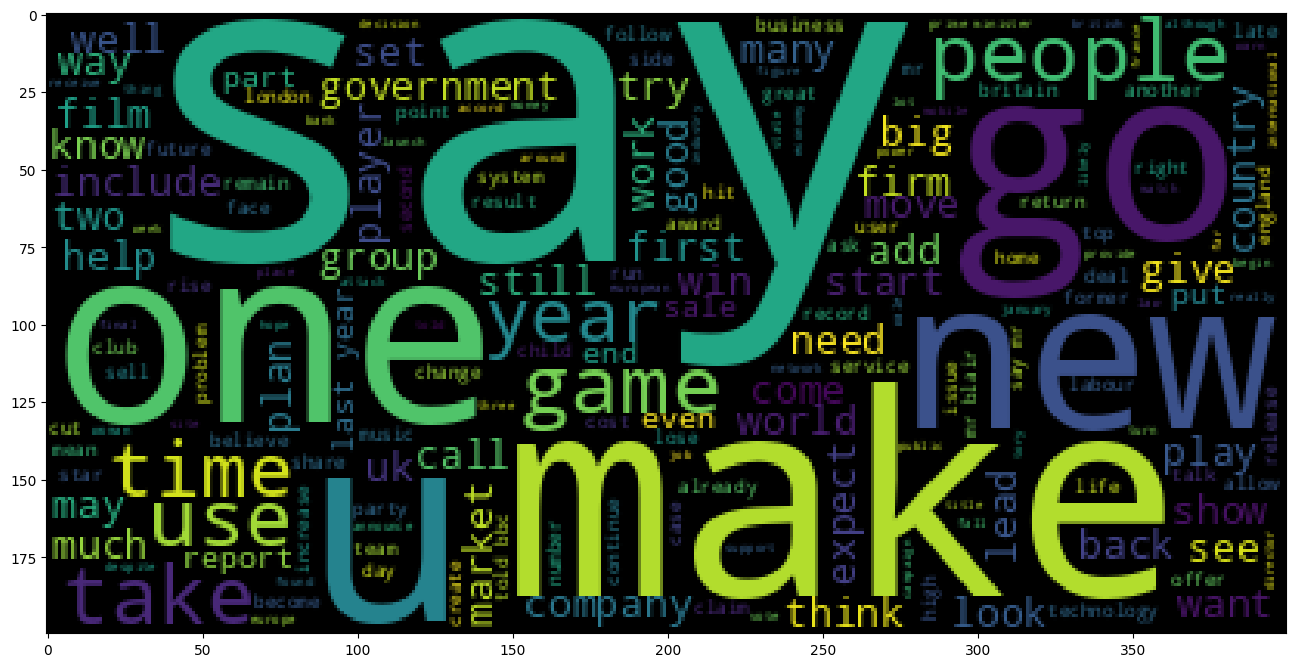

In [69]:
plt.figure(figsize=(16,9))
plt.imshow(wcloud)

In [70]:
swords.extend(['say','said','saying','make','made','one','u','new','new','go','gone','went'])

In [71]:
def clean_text(sent): 
    tokens1 = word_tokenize(sent)
    tokens2 = [token for token in tokens1 if token.isalpha()]
    tokens3 = [lemmatize(token.lower()) for token in tokens2 
              if token.lower() not in swords]
    return tokens3

In [72]:
tfidf = TfidfVectorizer(analyzer=clean_text)

In [73]:
x_new = tfidf.fit_transform(df['text'])

In [74]:
x_new.shape

(2225, 21405)

#### Identify the number of clusters

In [77]:
from sklearn.cluster import KMeans

In [83]:
km = KMeans(n_clusters=10, n_init='auto')

In [84]:
km.fit(x_new)

KMeans(n_clusters=10, n_init='auto')

In [85]:
km.inertia_

2064.677617898026

In [93]:
sse = []
for k in range(1,16):
    km = KMeans(n_clusters=k, n_init='auto', random_state=0)
    km.fit(x_new)
    sse.append(km.inertia_)

In [94]:
sse

[2163.6995630022716,
 2142.3089247249245,
 2126.11504703966,
 2117.747513737718,
 2098.2025167477723,
 2089.262846577058,
 2081.6439417214706,
 2072.342749219742,
 2065.320767604168,
 2061.12960779616,
 2052.618657634121,
 2046.3817941014283,
 2039.816059287163,
 2035.185428090256,
 2029.1987157713875]

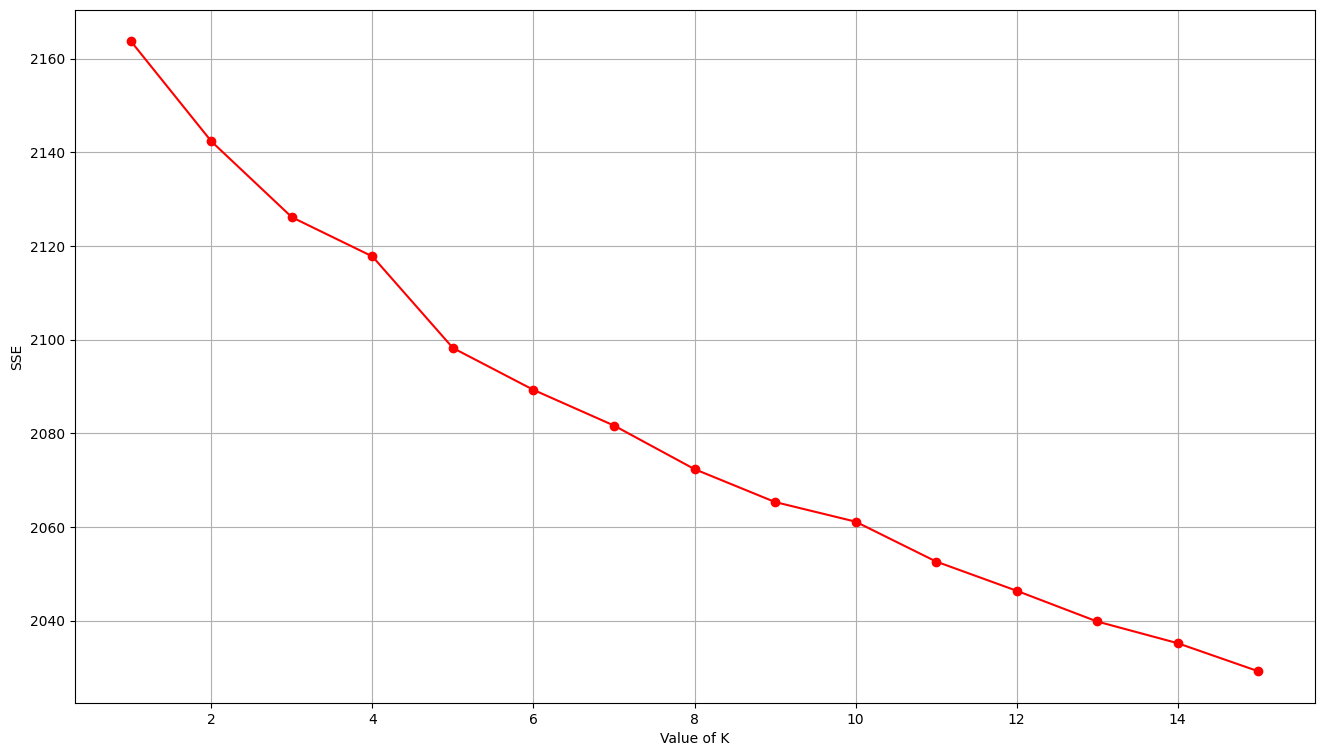

In [95]:
plt.figure(figsize=(16,9))
plt.grid()
plt.xlabel('Value of K')
plt.ylabel('SSE')
plt.plot(range(1,16), sse, marker = 'o', color = 'red')

In [96]:
pip install kneed

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [97]:
from kneed import KneeLocator

In [98]:
kl = KneeLocator(range(1,16), sse, curve='convex', direction='decreasing')

In [99]:
kl.elbow

5

#### Create the clusters

In [101]:
km = KMeans(n_clusters=5, n_init='auto', random_state=0)

In [102]:
labels = km.fit_predict(x_new)

In [103]:
labels

array([4, 3, 4, ..., 3, 3, 3], dtype=int32)

In [123]:
zero = df['text'][labels==0]
one = df['text'][labels==1]
two = df['text'][labels==2]
three = df['text'][labels==3]
four = df['text'][labels==4]

In [109]:
zero.shape, one.shape, two.shape, three.shape, four.shape

((376,), (355,), (517,), (693,), (284,))

In [112]:
zero = " ".join(zero.apply(clean_text).sum())

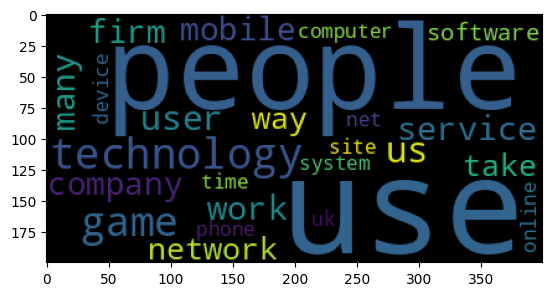

In [114]:
zero_wcloud = WordCloud(max_words=25).generate(zero)
plt.imshow(zero_wcloud)

In [117]:
zero_wcloud.words_

{'use': 1.0,
 'people': 0.7073490813648294,
 'technology': 0.6732283464566929,
 'game': 0.6351706036745407,
 'us': 0.4881889763779528,
 'user': 0.45931758530183725,
 'service': 0.4343832020997375,
 'work': 0.4199475065616798,
 'company': 0.4041994750656168,
 'many': 0.39763779527559057,
 'firm': 0.39763779527559057,
 'mobile': 0.39501312335958005,
 'network': 0.3779527559055118,
 'take': 0.3766404199475066,
 'way': 0.3674540682414698,
 'software': 0.35958005249343833,
 'computer': 0.35826771653543305,
 'uk': 0.35826771653543305,
 'time': 0.35826771653543305,
 'net': 0.3464566929133858,
 'site': 0.33989501312335957,
 'system': 0.3228346456692913,
 'phone': 0.32020997375328086,
 'online': 0.31496062992125984,
 'device': 0.3110236220472441}

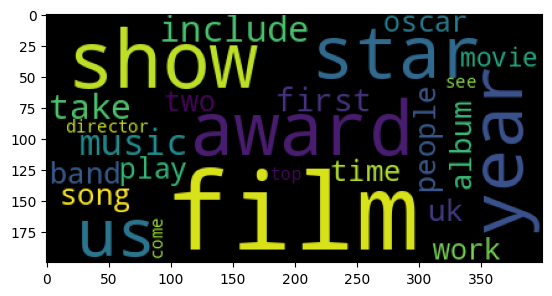

In [118]:
one = " ".join(one.apply(clean_text).sum())
one_wcloud = WordCloud(max_words=25).generate(one)
plt.imshow(one_wcloud)

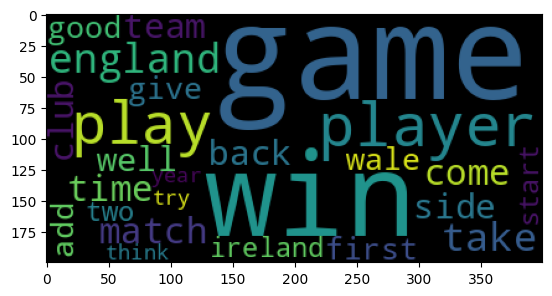

In [119]:
two = " ".join(two.apply(clean_text).sum())
two_wcloud = WordCloud(max_words=25).generate(two)
plt.imshow(two_wcloud)

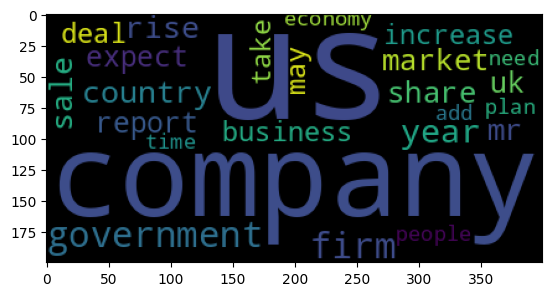

In [124]:
three = " ".join(three.apply(clean_text).sum())
three_wcloud = WordCloud(max_words=25).generate(three)
plt.imshow(three_wcloud)

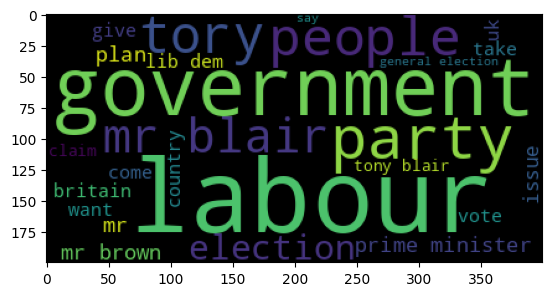

In [125]:
four = " ".join(four.apply(clean_text).sum())
four_wcloud = WordCloud(max_words=25).generate(four)
plt.imshow(four_wcloud)

In [126]:
new_text = '''PSG will make a move to sign Bournemouth forward Eli Junior Kroupi, who has been linked with Arsenal - L'Equipe
Manchester United fear Marcus Rashford's future might not get resolved until after the World Cup, which would seriously hamper the club's summer transfer business - Daily Mirror
Manchester United and Arsenal target Mateus Fernandes is valued at £80m by relegated West Ham - The Sun
Liverpool transfer target Yan Diomande is favouring a move to Paris Saint-Germain. The young Ivory Coast ace has been identified as an ideal replacement for Mohamed Salah - Foot Mercato
Newcastle have identified Atalanta's Italy right-back Marco Palestra as a summer target but could face competition from Manchester City, Arsenal and Inter Milan - Daily Mail
Also See:
Transfer Centre LIVE!
Download the Sky Sports app
Stream Sky Sports with NOW
Get Sky Sports on WhatsAp
Manchester United are interested in landing Middlesbrough midfielder Hayden Hackney - The Northern Echo
Manchester United have offered Harry Maguire to Inter Milan - La Gazzetta dello Sport
Arsenal teenager Josh Nichols has confirmed he will be leaving the club. The 19-year-old will be departing north London to move to Croatian side NK Kustosija - Daily Mirror
Transfer Centre LIVE! | Latest on YOUR PL club!
Sky Sports Rewards - tickets, offers and more
Download the Sky Sports app for expert analysis, best video & more
Not got Sky? Get Sky Sports or stream with no contract on NOW
Fenerbahce presidential candidate Hakan Safi has ruled out a move for Manchester United target Rafael Leao this summer - Daily Mirror
Tottenham Hotspur have been handed a boost this summer with talented teen Luka Vuskovic focused on the World Cup and not a transfer - talkSPORT
Watch Back Pages on Sky Sports News
Back Pages is a review of the sports headlines from the national newspapers, every Monday to Friday, live on Sky Sports News from 10.30pm.
Missed the show? Catch up on the latest news with the Back Pages podcast.
World Cup
William Saliba could miss the World Cup after flaring up a pre-existing back injury during the Champions League final - The Sun
World football
Pep Guardiola will snub an approach from Sir David Beckham to become the new Inter Miami manager - Daily Mirror
Real Madrid could have to pay up to £13m to secure Jose Mourinho's appointment as manager following the expiration of a break clause in the 63-year-old's contract at Benfica - The Athletic
Saido Berahino has joined the coaching staff of the Burundi national team after retiring from football - The Sun'''

In [127]:
new_text = tfidf.transform([new_text])

In [128]:
km.predict(new_text)

array([2], dtype=int32)